In [1]:
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import re
import requests
import os

In [2]:
# Base path to CSV files
base_path = "/Users/emmagregory/Documents/Predicting London Property Prices/Property_data_by_area/"

# List of all borough CSV files 
borough_files = [
    'Barking_and_Dagenham.csv',
    'Barnet.csv',
    'Bexley.csv',
    'Brent.csv',
    'Brentwood.csv',
    'Bromley.csv',
    'Camden.csv',
    'City_of_London.csv',
    'Croydon.csv',
    'Ealing.csv',
    'Enfield.csv',
    'Greenwich.csv',
    'Hackney.csv',
    'Hammersmith_and_Fulham.csv',
    'Haringey.csv',
    'Harrow.csv',
    'Havering.csv',
    'Hillingdon.csv',
    'Hounslow.csv',
    'Islington.csv',
    'Kensington_and_Chelsea.csv',
    'Kingston_upon_Thames.csv',
    'Lambeth.csv',
    'Lewisham.csv',
    'Merton.csv',
    'Newham.csv',
    'Redbridge.csv',
    'Richmond_upon_Thames.csv',
    'Southwark.csv',
    'Sutton.csv',
    'Tower_Hamlets.csv',
    'Waltham_Forest.csv',
    'Wandsworth.csv',
    'Westminster.csv'
]

# Method 1: Create numbered DataFrames (df1, df2, df3, etc.)
dataframes = {}
for i, filename in enumerate(borough_files, start=1):
    filepath = os.path.join(base_path, filename)
    df_name = f'df{i}'
    dataframes[df_name] = pd.read_csv(filepath)



In [3]:
# Remove rows with 0 area from all DataFrames


for i, filename in enumerate(borough_files, start=1):
    df_name = f'df{i}'
    borough_name = filename.replace('.csv', '')
    
    # Remove rows where tfarea is 0
    dataframes[df_name] = dataframes[df_name][dataframes[df_name]['tfarea'] != 0]
    

In [4]:
# Remove properties with area < 20 or > 400 from all borough DataFrames

for i, filename in enumerate(borough_files, start=1):
    df_name = f'df{i}'
    borough_name = filename.replace('.csv', '')
    
    # Remove rows where tfarea is < 20 or > 400
    dataframes[df_name] = dataframes[df_name][
        (dataframes[df_name]['tfarea'] >= 20) & 
        (dataframes[df_name]['tfarea'] <= 400)
    ]

In [5]:
# Remove prices < 10 000
for i, filename in enumerate(borough_files, start=1):
    df_name = f'df{i}'
    borough_name = filename.replace('.csv', '')
    
    # Remove rows where price is <= 10 000
    dataframes[df_name] = dataframes[df_name][
        (dataframes[df_name]['price'] >= 20) 
    ]


In [6]:
# Add outbound postcode column to all DataFrames

for i, filename in enumerate(borough_files, start=1):
    df_name = f'df{i}'
    borough_name = filename.replace('.csv', '')
    
    # Extract outbound postcode (part before the space)
    dataframes[df_name]['outbound_postcode'] = dataframes[df_name]['postcode'].str.split().str[0]


In [7]:
# Create borough_outbound column (borough number + outbound postcode)

for i, filename in enumerate(borough_files, start=1):
    df_name = f'df{i}'
    borough_name = filename.replace('.csv', '')
    
    # Create borough_outbound column (e.g., "1_E8", "12_N16")
    dataframes[df_name]['borough_outbound'] = str(i) + '_' + dataframes[df_name]['outbound_postcode']



In [8]:
# Combine all DataFrames with detailed reporting

all_dfs = []

for i, filename in enumerate(borough_files, start=1):
    df_name = f'df{i}'
    borough_name = filename.replace('.csv', '')
    
    # Add identifying columns
    temp_df = dataframes[df_name].copy()
    temp_df['borough_name'] = borough_name
    temp_df['borough_id'] = i
    
    all_dfs.append(temp_df)

# Combine
all_property_data = pd.concat(all_dfs, ignore_index=True)


# Save to CSV
output_path = base_path + "all_property_data.csv"
all_property_data.to_csv(output_path, index=False)



In [9]:
all_property_data.head()

,priceper,year,dateoftransfer,propertytype,duration,price,postcode,lad23cd,transactionid,lmk_key,tfarea,numberrooms,classt,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY,CONSTRUCTION_AGE_BAND,outbound_postcode,borough_outbound,borough_name,borough_id
0,4206.349206,2023,2023-11-28,F,L,265000,IG11 7GW,E09000002,{152AB733-B73B-E651-E063-4704A8C061D9},5a6e6b6a24c2a840e15b66b8abcb70c3d09b4096b2f5e2...,63.00,3.0,12,76,79,England and Wales: 1996-2002,IG11,1_IG11,Barking_and_Dagenham,1
1,4259.259259,2017,2017-06-28,F,L,230000,IG11 0XU,E09000002,{55BDCAE5-D63C-521D-E053-6B04A8C0DD7A},1516080632712017020216430198030049,54.00,3.0,11,80,80,England and Wales: 1996-2002,IG11,1_IG11,Barking_and_Dagenham,1
2,3964.285714,2019,2019-12-13,S,F,333000,RM10 9RJ,E09000002,{9DBAD221-9A19-6EB3-E053-6B04A8C0F257},302069721132019091122222395068202,84.00,3.0,12,62,84,England and Wales: 1930-1949,RM10,1_RM10,Barking_and_Dagenham,1
3,4381.161008,2022,2022-12-09,F,L,200000,IG11 8RR,E09000002,{F87E72F9-8070-176C-E053-6B04A8C0D2BE},446368229262010022820145253538650,45.65,2.0,11,82,82,England and Wales: 2003-2006,IG11,1_IG11,Barking_and_Dagenham,1
4,4455.284553,2016,2016-11-11,S,F,548000,IG11 9HD,E09000002,{453D27A2-E9AE-EF91-E050-A8C0630574D7},1442699394912016051221163296960046,123.00,6.0,11,49,79,England and Wales: 1930-1949,IG11,1_IG11,Barking_and_Dagenham,1


CREATING CUSTOM AREA BINS (5 GROUPS)

Distribution of properties across bins:
Bin                  Range (sqm)          Count        Percentage   Mean Area    Mean Price
----------------------------------------------------------------------------------------------------
Q1 (20-59)           20.0-59.0 sqm     208,976      24.91%         48.0 sqm   £   359,540
Q2 (59-78)           59.0-77.6 sqm     211,633      25.22%         68.7 sqm   £   454,960
Q3 (78-103)          77.6-103.0 sqm     212,881      25.37%         88.8 sqm   £   574,112
Q4a (103-150)        103.0-150.0 sqm     141,151      16.82%        122.2 sqm   £   819,107
Q4b (150-400)        150.0-400.0 sqm     64,411        7.68%        199.4 sqm   £ 1,697,591

TOTAL                20.0-400.0 sqm       839,052      100.00%

COMPARISON: NEW 5 BINS vs ORIGINAL 4 QUARTILES

Original 4 quartiles:
--------------------------------------------------------------------------------
Original_Q1          20.0-59.5 sqm     209,769      25.00%

/var/folders/yn/ddp2vn2s1dggnwr4swrdpbw40000gn/T/ipykernel_11236/4181717898.py:127: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 1].boxplot(bin_data, labels=['Q1', 'Q2', 'Q3', 'Q4a', 'Q4b'])


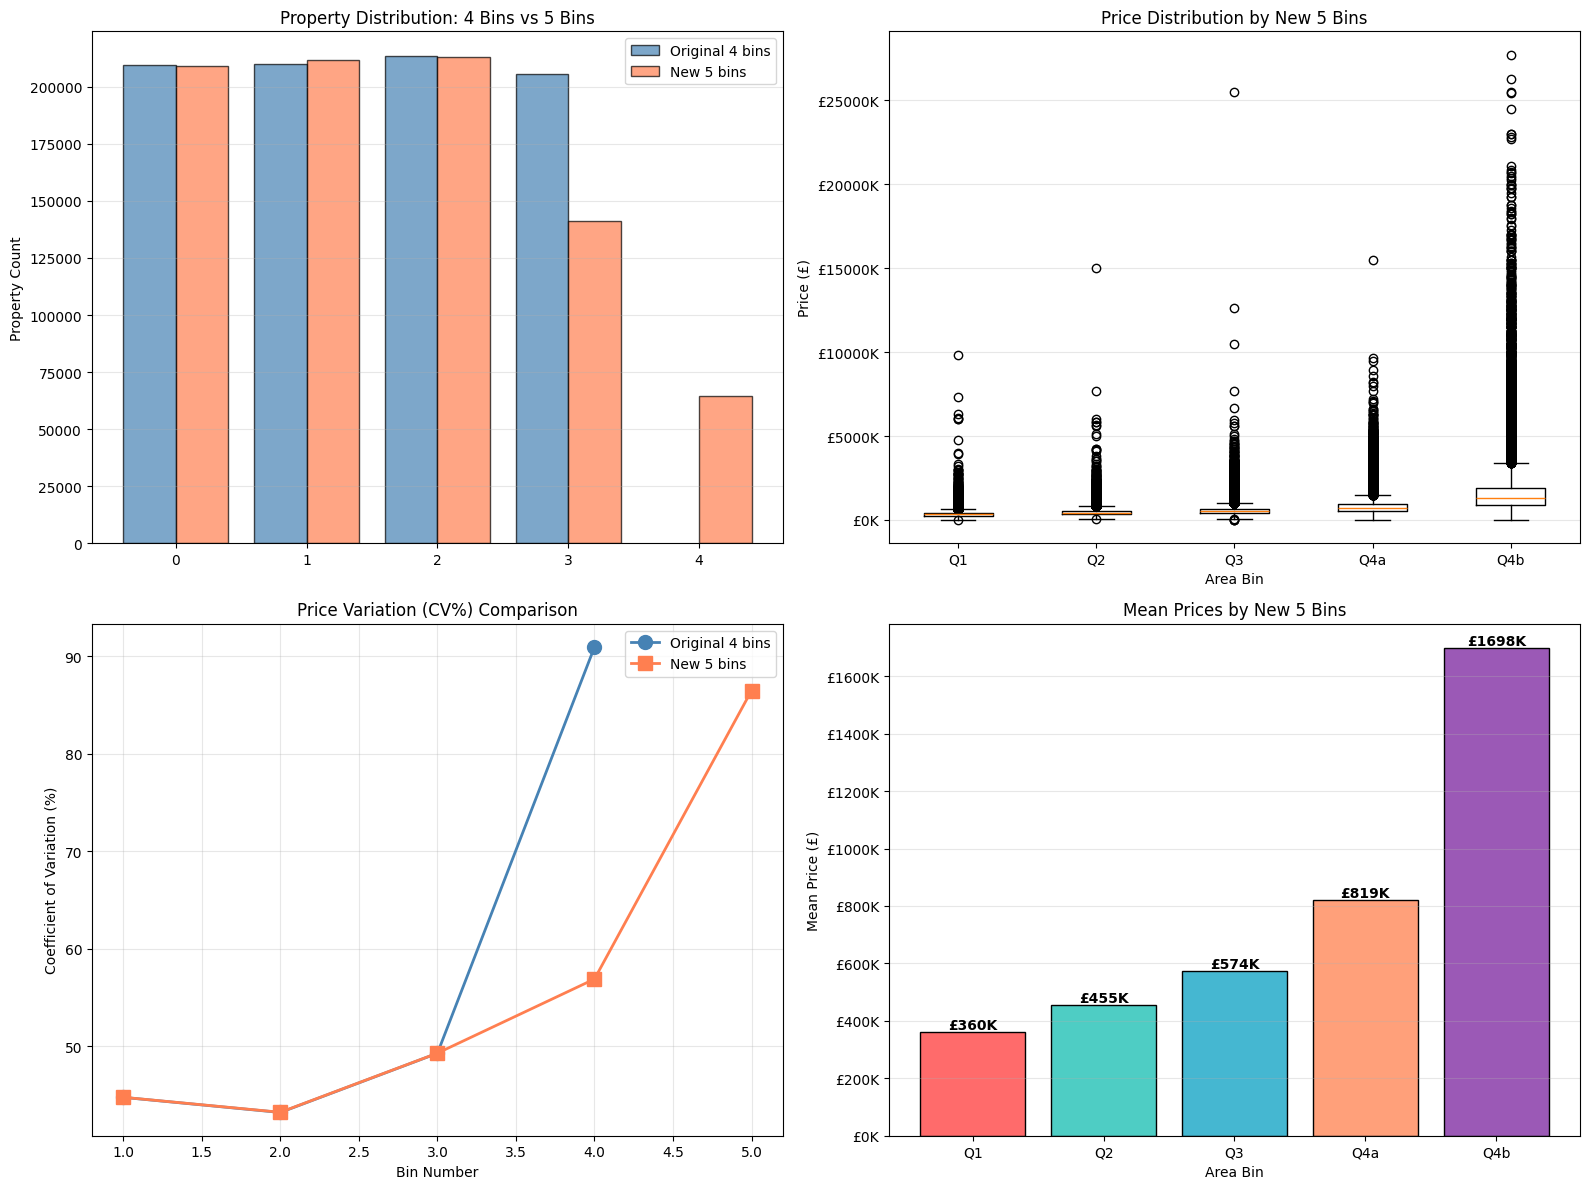


✓ Custom bins created and analyzed!


In [13]:
# Create custom area bins with Q4 split into two groups

print("="*80)
print("CREATING CUSTOM AREA BINS (5 GROUPS)")
print("="*80)

# Define custom bins
bins = [20, 59, 77.6, 103, 150, 400]
labels = ['Q1 (20-59)', 'Q2 (59-78)', 'Q3 (78-103)', 'Q4a (103-150)', 'Q4b (150-400)']

# Create the new area_bin column
all_property_data['area_bin'] = pd.cut(
    all_property_data['tfarea'], 
    bins=bins, 
    labels=labels,
    include_lowest=True
)

# Show distribution
print("\nDistribution of properties across bins:")
print("="*80)
print(f"{'Bin':<20} {'Range (sqm)':<20} {'Count':<12} {'Percentage':<12} {'Mean Area':<12} {'Mean Price'}")
print("-"*100)

for label in labels:
    subset = all_property_data[all_property_data['area_bin'] == label]
    count = len(subset)
    pct = count / len(all_property_data) * 100
    mean_area = subset['tfarea'].mean()
    mean_price = subset['price'].mean()
    
    print(f"{label:<20} {subset['tfarea'].min():.1f}-{subset['tfarea'].max():.1f} sqm     "
          f"{count:<12,} {pct:>5.2f}%       {mean_area:>6.1f} sqm   £{mean_price:>10,.0f}")

print(f"\n{'TOTAL':<20} {'20.0-400.0 sqm':<20} {len(all_property_data):<12,} 100.00%")

# Compare to original 4 quartiles
print("\n" + "="*80)
print("COMPARISON: NEW 5 BINS vs ORIGINAL 4 QUARTILES")
print("="*80)

# Create original quartile bins for comparison
all_property_data['area_bin_original'] = pd.qcut(
    all_property_data['tfarea'], 
    q=4, 
    labels=['Original_Q1', 'Original_Q2', 'Original_Q3', 'Original_Q4'],
    duplicates='drop'
)

print("\nOriginal 4 quartiles:")
print("-"*80)
for q in ['Original_Q1', 'Original_Q2', 'Original_Q3', 'Original_Q4']:
    subset = all_property_data[all_property_data['area_bin_original'] == q]
    count = len(subset)
    pct = count / len(all_property_data) * 100
    print(f"{q:<20} {subset['tfarea'].min():.1f}-{subset['tfarea'].max():.1f} sqm     "
          f"{count:<12,} {pct:>5.2f}%")

print("\nNew 5 bins:")
print("-"*80)
for label in labels:
    subset = all_property_data[all_property_data['area_bin'] == label]
    count = len(subset)
    pct = count / len(all_property_data) * 100
    print(f"{label:<20} {subset['tfarea'].min():.1f}-{subset['tfarea'].max():.1f} sqm     "
          f"{count:<12,} {pct:>5.2f}%")

# Effect analysis
print("\n" + "="*80)
print("EFFECT OF SPLITTING Q4")
print("="*80)

original_q4 = all_property_data[all_property_data['area_bin_original'] == 'Original_Q4']
new_q4a = all_property_data[all_property_data['area_bin'] == 'Q4a (103-150)']
new_q4b = all_property_data[all_property_data['area_bin'] == 'Q4b (150-400)']

print(f"\nOriginal Q4 (103-400 sqm):")
print(f"  Count: {len(original_q4):,}")
print(f"  Mean price: £{original_q4['price'].mean():,.0f}")
print(f"  Median price: £{original_q4['price'].median():,.0f}")
print(f"  Std dev: £{original_q4['price'].std():,.0f}")
print(f"  CV%: {(original_q4['price'].std() / original_q4['price'].mean() * 100):.2f}%")

print(f"\nNew Q4a (103-150 sqm):")
print(f"  Count: {len(new_q4a):,} ({len(new_q4a)/len(original_q4)*100:.1f}% of original Q4)")
print(f"  Mean price: £{new_q4a['price'].mean():,.0f}")
print(f"  Median price: £{new_q4a['price'].median():,.0f}")
print(f"  Std dev: £{new_q4a['price'].std():,.0f}")
print(f"  CV%: {(new_q4a['price'].std() / new_q4a['price'].mean() * 100):.2f}%")

print(f"\nNew Q4b (150-400 sqm):")
print(f"  Count: {len(new_q4b):,} ({len(new_q4b)/len(original_q4)*100:.1f}% of original Q4)")
print(f"  Mean price: £{new_q4b['price'].mean():,.0f}")
print(f"  Median price: £{new_q4b['price'].median():,.0f}")
print(f"  Std dev: £{new_q4b['price'].std():,.0f}")
print(f"  CV%: {(new_q4b['price'].std() / new_q4b['price'].mean() * 100):.2f}%")

print(f"\nReduction in variation by splitting Q4:")
print(f"  Original Q4 CV%: {(original_q4['price'].std() / original_q4['price'].mean() * 100):.2f}%")
print(f"  New Q4a CV%: {(new_q4a['price'].std() / new_q4a['price'].mean() * 100):.2f}%")
print(f"  New Q4b CV%: {(new_q4b['price'].std() / new_q4b['price'].mean() * 100):.2f}%")

# Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution comparison
bin_counts_new = [len(all_property_data[all_property_data['area_bin'] == label]) for label in labels]
bin_counts_old = [len(all_property_data[all_property_data['area_bin_original'] == q]) 
                  for q in ['Original_Q1', 'Original_Q2', 'Original_Q3', 'Original_Q4']]

x_new = range(len(labels))
x_old = range(len(bin_counts_old))

axes[0, 0].bar([i - 0.2 for i in x_old], bin_counts_old, width=0.4, label='Original 4 bins', 
               color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].bar([i + 0.2 for i in x_new], bin_counts_new, width=0.4, label='New 5 bins', 
               color='coral', edgecolor='black', alpha=0.7)
axes[0, 0].set_ylabel('Property Count')
axes[0, 0].set_title('Property Distribution: 4 Bins vs 5 Bins')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Price distributions for new bins
bin_data = [all_property_data[all_property_data['area_bin'] == label]['price'] for label in labels]
bp = axes[0, 1].boxplot(bin_data, labels=['Q1', 'Q2', 'Q3', 'Q4a', 'Q4b'])
axes[0, 1].set_ylabel('Price (£)')
axes[0, 1].set_xlabel('Area Bin')
axes[0, 1].set_title('Price Distribution by New 5 Bins')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}K'))

# 3. Coefficient of variation comparison
cv_old = [(all_property_data[all_property_data['area_bin_original'] == q]['price'].std() / 
           all_property_data[all_property_data['area_bin_original'] == q]['price'].mean() * 100)
          for q in ['Original_Q1', 'Original_Q2', 'Original_Q3', 'Original_Q4']]

cv_new = [(all_property_data[all_property_data['area_bin'] == label]['price'].std() / 
           all_property_data[all_property_data['area_bin'] == label]['price'].mean() * 100)
          for label in labels]

axes[1, 0].plot(range(1, 5), cv_old, marker='o', linewidth=2, markersize=10, 
                label='Original 4 bins', color='steelblue')
axes[1, 0].plot(range(1, 6), cv_new, marker='s', linewidth=2, markersize=10, 
                label='New 5 bins', color='coral')
axes[1, 0].set_xlabel('Bin Number')
axes[1, 0].set_ylabel('Coefficient of Variation (%)')
axes[1, 0].set_title('Price Variation (CV%) Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Mean prices by bin
mean_prices_new = [all_property_data[all_property_data['area_bin'] == label]['price'].mean() 
                   for label in labels]

axes[1, 1].bar(range(len(labels)), mean_prices_new, 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#9B59B6'], 
               edgecolor='black')
axes[1, 1].set_xticks(range(len(labels)))
axes[1, 1].set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4a', 'Q4b'])
axes[1, 1].set_ylabel('Mean Price (£)')
axes[1, 1].set_xlabel('Area Bin')
axes[1, 1].set_title('Mean Prices by New 5 Bins')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}K'))

# Add value labels
for i, v in enumerate(mean_prices_new):
    axes[1, 1].text(i, v, f'£{v/1000:.0f}K', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Custom bins created and analyzed!")

In [14]:
# Create summary CSV with year, borough_outbound, area_bin, and average price

print("="*80)
print("CREATING SUMMARY CSV")
print("="*80)

# Group by year, borough_outbound, and area_bin to get average prices
summary_data = all_property_data.groupby(
    ['year', 'borough_outbound', 'area_bin']
).agg({
    'price': 'mean',
    'tfarea': 'mean',  # Also include average area for reference
    'postcode': 'count'  # Count of properties
}).round(2)

# Rename columns
summary_data.columns = ['average_price', 'average_area', 'property_count']
summary_data = summary_data.reset_index()

# Rename area_bin values to simpler format
summary_data['area_bin'] = summary_data['area_bin'].astype(str).replace({
    'Q1 (20-59)': 'Q1',
    'Q2 (59-78)': 'Q2',
    'Q3 (78-103)': 'Q3',
    'Q4a (103-150)': 'Q4a',
    'Q4b (150-400)': 'Q4b'
})

print(f"\nTotal rows in summary: {len(summary_data):,}")
print(f"Years: {summary_data['year'].min()} - {summary_data['year'].max()}")
print(f"Unique borough_outbound codes: {summary_data['borough_outbound'].nunique()}")
print(f"Area bins: {summary_data['area_bin'].unique()}")

print("\nFirst 20 rows:")
print(summary_data.head(20).to_string(index=False))

# Save to CSV
output_path = base_path + "property_summary_year_borough_areabin.csv"
summary_data.to_csv(output_path, index=False)
print(f"\n✓ Saved to: {output_path}")

# Verify with example
print("\n" + "="*80)
print("EXAMPLE: 1_E9 (if it exists)")
print("="*80)

example_data = summary_data[summary_data['borough_outbound'].str.contains('1_E9', na=False)]
if len(example_data) > 0:
    print(f"\nFound {len(example_data)} rows for borough_outbound codes containing '1_E9'")
    print("\nData for 1_E9:")
    print(example_data.to_string(index=False))
    
    # Check how many years and bins
    years = example_data['year'].nunique()
    bins = example_data['area_bin'].nunique()
    print(f"\nYears covered: {years}")
    print(f"Area bins covered: {bins}")
    print(f"Total rows: {len(example_data)} (expected: {years} years × {bins} bins = {years * bins})")
else:
    print("No data found for '1_E9' - trying another example...")
    
    # Find any outbound code from borough 1
    borough_1_codes = summary_data[summary_data['borough_outbound'].str.startswith('1_')]['borough_outbound'].unique()
    if len(borough_1_codes) > 0:
        example_code = borough_1_codes[0]
        print(f"\nExample with {example_code}:")
        example_data = summary_data[summary_data['borough_outbound'] == example_code]
        print(example_data.to_string(index=False))

# Statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print(f"\nTotal combinations: {len(summary_data):,}")
print(f"Combinations with data: {len(summary_data):,}")

# Count by area bin
print("\nRows per area bin:")
print(summary_data['area_bin'].value_counts().sort_index())

# Count by year
print("\nRows per year:")
print(summary_data['year'].value_counts().sort_index())

# Average properties per combination
print(f"\nAverage properties per combination: {summary_data['property_count'].mean():.1f}")
print(f"Median properties per combination: {summary_data['property_count'].median():.0f}")
print(f"Min properties per combination: {summary_data['property_count'].min():.0f}")
print(f"Max properties per combination: {summary_data['property_count'].max():.0f}")

# Combinations with few properties
print(f"\nCombinations with <5 properties: {len(summary_data[summary_data['property_count'] < 5]):,}")
print(f"Combinations with <10 properties: {len(summary_data[summary_data['property_count'] < 10]):,}")

CREATING SUMMARY CSV

Total rows in summary: 22,200
Years: 2015 - 2024
Unique borough_outbound codes: 444
Area bins: ['Q1' 'Q2' 'Q3' 'Q4a' 'Q4b']

First 20 rows:
 year borough_outbound area_bin  average_price  average_area  property_count
 2015           10_HA0       Q1      222000.00         36.67               3
 2015           10_HA0       Q2      380666.67         70.40               3
 2015           10_HA0       Q3      225000.00         79.00               1
 2015           10_HA0      Q4a      275000.00        110.00               1
 2015           10_HA0      Q4b            NaN           NaN               0
 2015          10_NW10       Q1      302177.12         47.88              17
 2015          10_NW10       Q2      421000.00         69.32               5
 2015          10_NW10       Q3      483987.29         88.50              21
 2015          10_NW10      Q4a      650000.00        108.00               1
 2015          10_NW10      Q4b      650000.00        158.00        

/var/folders/yn/ddp2vn2s1dggnwr4swrdpbw40000gn/T/ipykernel_11236/1281340403.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_data = all_property_data.groupby(



✓ Saved to: /Users/emmagregory/Documents/Predicting London Property Prices/Property_data_by_area/property_summary_year_borough_areabin.csv

EXAMPLE: 1_E9 (if it exists)

Found 50 rows for borough_outbound codes containing '1_E9'

Data for 1_E9:
 year borough_outbound area_bin  average_price  average_area  property_count
 2015            31_E9       Q1      315750.00         36.04               2
 2015            31_E9       Q2      500000.00         72.00               1
 2015            31_E9       Q3            NaN           NaN               0
 2015            31_E9      Q4a            NaN           NaN               0
 2015            31_E9      Q4b            NaN           NaN               0
 2016            31_E9       Q1            NaN           NaN               0
 2016            31_E9       Q2            NaN           NaN               0
 2016            31_E9       Q3            NaN           NaN               0
 2016            31_E9      Q4a            NaN           NaN 

In [18]:
# Create postcode to borough_outbound lookup


# Get unique postcode to borough_outbound mappings
postcode_lookup = all_property_data[['postcode', 'borough_outbound', 'borough_name', 'borough_id']].drop_duplicates()

# Sort for easier reading
postcode_lookup = postcode_lookup.sort_values(['borough_id', 'postcode']).reset_index(drop=True)

# Save to CSV
lookup_path = base_path + "postcode_to_borough_outbound_lookup.csv"
postcode_lookup.to_csv(lookup_path, index=False)



In [21]:
postcode_lsoa = pd.read_csv('/Users/emmagregory/Documents/Predicting London Property Prices/PTAL/london_postcode_lsoa_lookup.csv')

In [22]:
postcode_lsoa.head()

,pcds,lsoa11cd
0,BR1 1AA,E01000675
1,BR1 1AB,E01000676
2,BR1 1AD,E01000675
3,BR1 1AE,E01000677
4,BR1 1AF,E01000675


In [24]:
PTAL_15 = pd.read_csv('/Users/emmagregory/Documents/Predicting London Property Prices/PTAL/PTAL_2015.csv')

In [25]:
PTAL_15.head()

,,PTAL_2015
LSOA2001,PTAI2015,PTAL
E01000001,69.8233,6b
E01000002,83.782,6b
E01000003,41.7417,6b
E01000004,94.648,6b


In [32]:
# Reload PTAL_15 properly - skip the first row which seems to be a header
PTAL_15 = pd.read_csv('/Users/emmagregory/Documents/Predicting London Property Prices/PTAL/PTAL_2015.csv', 
                      skiprows=1,
                      names=['LSOA2001', 'PTAI2015', 'PTAL'])

# Convert PTAI2015 to numeric
PTAL_15['PTAI2015'] = pd.to_numeric(PTAL_15['PTAI2015'], errors='coerce')

print("Fixed PTAL_15:")
print(PTAL_15.head(10))
print(f"\nShape: {PTAL_15.shape}")
print("\nColumn types:")
print(PTAL_15.dtypes)

# Now do the merge
postcode_ptal = postcode_lsoa.merge(
    PTAL_15[['LSOA2001', 'PTAI2015', 'PTAL']],
    left_on='lsoa11cd',
    right_on='LSOA2001',
    how='left'
)

# Merge with borough_outbound
postcode_ptal_borough = postcode_ptal.merge(
    postcode_lookup[['postcode', 'borough_outbound']],
    left_on='pcds',
    right_on='postcode',
    how='left'
)

# Create final lookup
final_lookup = postcode_ptal_borough[['lsoa11cd', 'PTAI2015', 'PTAL', 'pcds', 'borough_outbound']].copy()
final_lookup.columns = ['lsoa', 'ptal_score', 'ptal_rating', 'postcode', 'borough_outbound']

# Calculate mean PTAL by LSOA
lsoa_ptal_summary = final_lookup.groupby('lsoa').agg({
    'ptal_score': 'mean',
    'ptal_rating': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],
    'postcode': 'first',
    'borough_outbound': 'first'
}).reset_index()

lsoa_ptal_summary.columns = ['lsoa', 'mean_ptal_score', 'ptal_rating', 'sample_postcode', 'borough_outbound']

print(f"\nTotal LSOAs: {len(lsoa_ptal_summary):,}")
print("\nFirst 10 rows:")
print(lsoa_ptal_summary.head(10))

# Save to CSV
output_path = base_path + "lsoa_ptal_postcode_borough_lookup.csv"
lsoa_ptal_summary.to_csv(output_path, index=False)
print(f"\n✓ Saved to: {output_path}")

Fixed PTAL_15:
    LSOA2001  PTAI2015  PTAL
0   LSOA2001       NaN  PTAL
1  E01000001  69.82330    6b
2  E01000002  83.78200    6b
3  E01000003  41.74170    6b
4  E01000004  94.64800    6b
5  E01000005  85.88930    6b
6  E01000006  22.45580     5
7  E01000007  33.30230    6a
8  E01000008   7.39059     2
9  E01000009  38.36410    6a

Shape: (4766, 3)

Column types:
LSOA2001     object
PTAI2015    float64
PTAL         object
dtype: object

Total LSOAs: 11,655

First 10 rows:
        lsoa  mean_ptal_score ptal_rating sample_postcode borough_outbound
0  E01000001         69.82330          6b        EC1A 4AA           8_EC1A
1  E01000002         83.78200          6b        EC1Y 4AG           8_EC2Y
2  E01000003         41.74170          6b        EC1M 7AA           8_EC1Y
3  E01000005         85.88930          6b          E1 7AA             8_E1
4  E01000006         22.45580           5        IG11 9SU           1_IG11
5  E01000007         33.30230          6a        IG11 8AH           1_IG

In [33]:
# Remove the header row that got included as data
PTAL_15 = PTAL_15[PTAL_15['LSOA2001'] != 'LSOA2001'].reset_index(drop=True)

print("Cleaned PTAL_15:")
print(PTAL_15.head(10))
print(f"\nShape: {PTAL_15.shape}")

# Now redo the merge with cleaned data
postcode_ptal = postcode_lsoa.merge(
    PTAL_15[['LSOA2001', 'PTAI2015', 'PTAL']],
    left_on='lsoa11cd',
    right_on='LSOA2001',
    how='left'
)

postcode_ptal_borough = postcode_ptal.merge(
    postcode_lookup[['postcode', 'borough_outbound']],
    left_on='pcds',
    right_on='postcode',
    how='left'
)

final_lookup = postcode_ptal_borough[['lsoa11cd', 'PTAI2015', 'PTAL', 'pcds', 'borough_outbound']].copy()
final_lookup.columns = ['lsoa', 'ptal_score', 'ptal_rating', 'postcode', 'borough_outbound']

lsoa_ptal_summary = final_lookup.groupby('lsoa').agg({
    'ptal_score': 'mean',
    'ptal_rating': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],
    'postcode': 'first',
    'borough_outbound': 'first'
}).reset_index()

lsoa_ptal_summary.columns = ['lsoa', 'mean_ptal_score', 'ptal_rating', 'sample_postcode', 'borough_outbound']

print(f"\nTotal LSOAs: {len(lsoa_ptal_summary):,}")
print("\nFirst 10 rows:")
print(lsoa_ptal_summary.head(10))

# Save cleaned version
output_path = base_path + "lsoa_ptal_postcode_borough_lookup.csv"
lsoa_ptal_summary.to_csv(output_path, index=False)
print(f"\n✓ Saved cleaned version to: {output_path}")

Cleaned PTAL_15:
    LSOA2001  PTAI2015 PTAL
0  E01000001  69.82330   6b
1  E01000002  83.78200   6b
2  E01000003  41.74170   6b
3  E01000004  94.64800   6b
4  E01000005  85.88930   6b
5  E01000006  22.45580    5
6  E01000007  33.30230   6a
7  E01000008   7.39059    2
8  E01000009  38.36410   6a
9  E01000010  32.28600   6a

Shape: (4765, 3)

Total LSOAs: 11,655

First 10 rows:
        lsoa  mean_ptal_score ptal_rating sample_postcode borough_outbound
0  E01000001         69.82330          6b        EC1A 4AA           8_EC1A
1  E01000002         83.78200          6b        EC1Y 4AG           8_EC2Y
2  E01000003         41.74170          6b        EC1M 7AA           8_EC1Y
3  E01000005         85.88930          6b          E1 7AA             8_E1
4  E01000006         22.45580           5        IG11 9SU           1_IG11
5  E01000007         33.30230          6a        IG11 8AH           1_IG11
6  E01000008          7.39059           2        IG11 8AD           1_IG11
7  E01000009        

In [34]:
print("="*80)
print("CREATING OUTBOUND_BOROUGH_PTAL MAPPING")
print("="*80)

# Group by borough_outbound and calculate average PTAL score
outbound_borough_ptal = lsoa_ptal_summary.groupby('borough_outbound').agg({
    'mean_ptal_score': 'mean',
    'ptal_rating': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],  # Most common rating
    'lsoa': 'count'  # Count of LSOAs per borough_outbound
}).reset_index()

# Rename columns
outbound_borough_ptal.columns = ['borough_outbound', 'average_ptal_score', 'most_common_ptal_rating', 'lsoa_count']

# Round the average PTAL score
outbound_borough_ptal['average_ptal_score'] = outbound_borough_ptal['average_ptal_score'].round(2)

# Sort by borough_outbound
outbound_borough_ptal = outbound_borough_ptal.sort_values('borough_outbound').reset_index(drop=True)

print(f"\nTotal borough_outbound codes: {len(outbound_borough_ptal):,}")
print(f"PTAL score range: {outbound_borough_ptal['average_ptal_score'].min():.2f} - {outbound_borough_ptal['average_ptal_score'].max():.2f}")

print("\nFirst 20 rows:")
print(outbound_borough_ptal.head(20).to_string(index=False))

# Save to CSV
output_path = base_path + "outbound_borough_ptal.csv"
outbound_borough_ptal.to_csv(output_path, index=False)
print(f"\n✓ Saved to: {output_path}")

# Show some statistics
print("\n" + "="*80)
print("STATISTICS")
print("="*80)
print(f"\nAverage PTAL score across all borough_outbound codes: {outbound_borough_ptal['average_ptal_score'].mean():.2f}")
print(f"Median PTAL score: {outbound_borough_ptal['average_ptal_score'].median():.2f}")
print(f"Std dev: {outbound_borough_ptal['average_ptal_score'].std():.2f}")

print("\nTop 10 highest PTAL scores:")
print(outbound_borough_ptal.nlargest(10, 'average_ptal_score')[['borough_outbound', 'average_ptal_score', 'most_common_ptal_rating']].to_string(index=False))

print("\nBottom 10 lowest PTAL scores:")
print(outbound_borough_ptal.nsmallest(10, 'average_ptal_score')[['borough_outbound', 'average_ptal_score', 'most_common_ptal_rating']].to_string(index=False))

CREATING OUTBOUND_BOROUGH_PTAL MAPPING

Total borough_outbound codes: 350
PTAL score range: 0.98 - 91.81

First 20 rows:
borough_outbound  average_ptal_score most_common_ptal_rating  lsoa_count
          10_HA0                4.23                      1b           2
         10_NW10               12.76                       3           5
          10_TW8                8.74                       2           1
          10_UB1                7.99                       2          28
          10_UB2                6.59                       2          14
          10_UB5                6.58                       2          26
          10_UB6                7.73                      1b          22
          10_W12               10.95                       3           1
          10_W13               12.00                       2          25
           10_W3               11.90                       2          30
           10_W4                9.76                       2           6
   

In [36]:
print("="*80)
print("CREATING OUTBOUND_BOROUGH_PTAL - FILTERED VERSION")
print("="*80)

# Filter to only include rows where we have both PTAL score AND borough_outbound
lsoa_ptal_filtered = lsoa_ptal_summary[
    (lsoa_ptal_summary['mean_ptal_score'].notna()) & 
    (lsoa_ptal_summary['borough_outbound'].notna())
].copy()

print(f"\nOriginal rows: {len(lsoa_ptal_summary):,}")
print(f"Filtered rows (with PTAL & borough_outbound): {len(lsoa_ptal_filtered):,}")
print(f"Rows removed: {len(lsoa_ptal_summary) - len(lsoa_ptal_filtered):,}")

# Now create the outbound_borough_ptal mapping
outbound_borough_ptal = lsoa_ptal_filtered.groupby('borough_outbound').agg({
    'mean_ptal_score': 'mean',
    'ptal_rating': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],
    'lsoa': 'count'
}).reset_index()

outbound_borough_ptal.columns = ['borough_outbound', 'average_ptal_score', 'most_common_ptal_rating', 'lsoa_count']
outbound_borough_ptal['average_ptal_score'] = outbound_borough_ptal['average_ptal_score'].round(2)
outbound_borough_ptal = outbound_borough_ptal.sort_values('borough_outbound').reset_index(drop=True)

print(f"\nTotal borough_outbound codes: {len(outbound_borough_ptal):,}")
print(f"PTAL score range: {outbound_borough_ptal['average_ptal_score'].min():.2f} - {outbound_borough_ptal['average_ptal_score'].max():.2f}")

# Check for any missing values
print("\nMissing values in final dataset:")
print(outbound_borough_ptal.isnull().sum())

print("\nFirst 20 rows:")
print(outbound_borough_ptal.head(20).to_string(index=False))

# Save to CSV
output_path = base_path + "outbound_borough_ptal.csv"
outbound_borough_ptal.to_csv(output_path, index=False)
print(f"\n✓ Saved to: {output_path}")

print("\nTop 10 highest PTAL scores:")
print(outbound_borough_ptal.nlargest(10, 'average_ptal_score')[['borough_outbound', 'average_ptal_score', 'most_common_ptal_rating']].to_string(index=False))

CREATING OUTBOUND_BOROUGH_PTAL - FILTERED VERSION

Original rows: 11,655
Filtered rows (with PTAL & borough_outbound): 4,635
Rows removed: 7,020

Total borough_outbound codes: 344
PTAL score range: 0.98 - 91.81

Missing values in final dataset:
borough_outbound           0
average_ptal_score         0
most_common_ptal_rating    0
lsoa_count                 0
dtype: int64

First 20 rows:
borough_outbound  average_ptal_score most_common_ptal_rating  lsoa_count
          10_HA0                4.23                      1b           2
         10_NW10               12.76                       3           5
          10_TW8                8.74                       2           1
          10_UB1                7.99                       2          26
          10_UB2                6.59                       2          14
          10_UB5                6.58                       2          26
          10_UB6                7.73                      1b          22
          10_W12          

In [42]:
PTAL_23 = pd.read_csv('/Users/emmagregory/Documents/Predicting London Property Prices/PTAL/PTAL_LSOA_2023.csv')

In [43]:
PTAL_23.head()

,LSOA21CD,LSOA21NM,borough,mean_AI,MEDIAN_AI,MIN_AI,MAX_AI,MEAN_PTAL_2023,Shape_Length,Shape_Area
0,E01000001,City of London 001A,City of London,74.818060,76.150404,43.344686,97.664050,6b,2635.767993,129865.314435
1,E01000002,City of London 001B,Islington,85.324898,88.899953,44.802674,102.127724,6b,2707.816821,228419.782304
2,E01000003,City of London 001C,Islington,53.411383,54.114541,36.995870,66.989479,6b,1224.573160,59054.204611
3,E01000005,City of London 001E,Tower Hamlets,82.428912,86.649985,45.504887,104.154096,6b,2275.805344,189577.709493
4,E01000006,Barking and Dagenham 016A,Barking & Dagenham,24.153971,27.931273,2.836977,33.400903,5,1966.092607,146536.995720


In [39]:
PTAL_15.head()

,LSOA2001,PTAI2015,PTAL
0,E01000001,69.8233,6b
1,E01000002,83.7820,6b
2,E01000003,41.7417,6b
3,E01000004,94.6480,6b
4,E01000005,85.8893,6b


In [40]:
postcode_lsoa.head()

,pcds,lsoa11cd
0,BR1 1AA,E01000675
1,BR1 1AB,E01000676
2,BR1 1AD,E01000675
3,BR1 1AE,E01000677
4,BR1 1AF,E01000675


In [44]:
print("="*80)
print("CREATING 2015_postcode_PTAL and 2023_postcode_PTAL")
print("="*80)

# ============================================================================
# 2015 FILE
# ============================================================================
print("\nCreating 2015_postcode_PTAL...")

ptal_2015_postcode = postcode_lsoa.merge(
    PTAL_15[['LSOA2001', 'PTAI2015']],
    left_on='lsoa11cd',
    right_on='LSOA2001',
    how='inner'
)[['pcds', 'PTAI2015']].copy()

ptal_2015_postcode.columns = ['postcode', 'mean_ptal']
ptal_2015_postcode = ptal_2015_postcode.sort_values('postcode').reset_index(drop=True)

output_path_2015 = base_path + "2015_postcode_PTAL.csv"
ptal_2015_postcode.to_csv(output_path_2015, index=False)

print(f"✓ 2015: {len(ptal_2015_postcode):,} postcodes")
print(ptal_2015_postcode.head(10))

# ============================================================================
# 2023 FILE
# ============================================================================
print("\n" + "="*80)
print("Creating 2023_postcode_PTAL...")

ptal_2023_postcode = postcode_lsoa.merge(
    PTAL_23[['LSOA21CD', 'mean_AI']],
    left_on='lsoa11cd',
    right_on='LSOA21CD',
    how='inner'
)[['pcds', 'mean_AI']].copy()

ptal_2023_postcode.columns = ['postcode', 'mean_ptal']
ptal_2023_postcode = ptal_2023_postcode.sort_values('postcode').reset_index(drop=True)

output_path_2023 = base_path + "2023_postcode_PTAL.csv"
ptal_2023_postcode.to_csv(output_path_2023, index=False)

print(f"✓ 2023: {len(ptal_2023_postcode):,} postcodes")
print(ptal_2023_postcode.head(10))

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"2015 file: {len(ptal_2015_postcode):,} postcodes")
print(f"2023 file: {len(ptal_2023_postcode):,} postcodes")
print(f"\n✓ Saved to:")
print(f"  {output_path_2015}")
print(f"  {output_path_2023}")

CREATING 2015_postcode_PTAL and 2023_postcode_PTAL

Creating 2015_postcode_PTAL...
✓ 2015: 300,386 postcodes
  postcode  mean_ptal
0  BR1 1AA    24.4005
1  BR1 1AB    28.5572
2  BR1 1AD    24.4005
3  BR1 1AE    21.1558
4  BR1 1AF    24.4005
5  BR1 1AG    24.4005
6  BR1 1AH    24.4005
7  BR1 1AJ    24.4005
8  BR1 1AL    28.5572
9  BR1 1AX    28.5572

Creating 2023_postcode_PTAL...
✓ 2023: 298,647 postcodes
  postcode  mean_ptal
0  BR1 1AB  26.784092
1  BR1 1AE  17.708293
2  BR1 1AL  26.784092
3  BR1 1AX  26.784092
4  BR1 1BA  17.241877
5  BR1 1BB  17.241877
6  BR1 1BP   8.445450
7  BR1 1BS  26.784092
8  BR1 1BT  14.893089
9  BR1 1BU   8.445450

SUMMARY
2015 file: 300,386 postcodes
2023 file: 298,647 postcodes

✓ Saved to:
  /Users/emmagregory/Documents/Predicting London Property Prices/Property_data_by_area/2015_postcode_PTAL.csv
  /Users/emmagregory/Documents/Predicting London Property Prices/Property_data_by_area/2023_postcode_PTAL.csv
